# 25. SDXL Inpainting Restoration

This notebook runs the SDXL Inpainting baseline on the controlled 50-painting subset.

The notebook proceeds in stages:

1. load configuration and damaged-input metadata,
2. validate inputs,
3. run a small smoke test,
4. visually inspect smoke-test outputs,
5. run the full SDXL restoration pipeline,
6. validate and summarize the final restoration metadata.

Zero-control cases are copied directly rather than passed through SDXL inference.

This keeps the SDXL branch methodologically aligned with the Stable Diffusion branch while allowing us to test whether a stronger generative inpainting model better balances visual plausibility and reference-faithful restoration.

## SDXL restoration strategy

The SDXL branch is evaluated as a generative inpainting baseline.

Important methodological notes:

- `zero_control` cases are copied directly,
- non-zero mask cases are restored with SDXL,
- restored outputs are saved at `768 × 768`,
- the metadata contract should match the other restoration branches,
- we first run a small smoke subset before launching the full 250-case run.

This notebook focuses only on restoration generation. Metrics and reports will be computed in later SDXL notebooks.

In [2]:
from pathlib import Path
import sys

import pandas as pd
import yaml
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display

import torch

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print("Enabled TF32 acceleration.")

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

src_path = PROJECT_ROOT / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("Project root:", PROJECT_ROOT)

Enabled TF32 acceleration.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval


In [2]:
config_path = PROJECT_ROOT / "config" / "experiment_50_config.yaml"

if not config_path.exists():
    raise FileNotFoundError(f"Config file not found: {config_path}")

with open(config_path, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

paths_cfg = config["paths"]

processed_metadata_dir = PROJECT_ROOT / paths_cfg.get(
    "processed_metadata_dir",
    "data/processed/metadata",
)

restored_root_dir = PROJECT_ROOT / paths_cfg.get(
    "processed_restored_dir",
    paths_cfg.get("restored_dir", "data/processed/restored"),
)

# Canonical damaged metadata file created by Notebook 04.
damaged_metadata_path = processed_metadata_dir / "metadata_damaged_images.csv"

sdxl_output_dir = restored_root_dir / "sdxl_inpainting"
sdxl_output_metadata_path = processed_metadata_dir / "metadata_restored_sdxl.csv"

sdxl_output_dir.mkdir(parents=True, exist_ok=True)
processed_metadata_dir.mkdir(parents=True, exist_ok=True)

if not damaged_metadata_path.exists():
    raise FileNotFoundError(
        f"Damaged metadata file not found: {damaged_metadata_path}"
    )

print("Processed metadata dir:", processed_metadata_dir)
print("Restored root dir:", restored_root_dir)
print("Damaged metadata path:", damaged_metadata_path)
print("SDXL output dir:", sdxl_output_dir)
print("SDXL output metadata path:", sdxl_output_metadata_path)

Processed metadata dir: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata
Restored root dir: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\restored
Damaged metadata path: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_damaged_images.csv
SDXL output dir: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\restored\sdxl_inpainting
SDXL output metadata path: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_sdxl.csv


In [3]:
from restoration_eval.restoration_sdxl import (
    MODEL_NAME,
    HF_MODEL_ID,
    DEFAULT_PROMPT,
    DEFAULT_NEGATIVE_PROMPT,
    run_sdxl_restoration_pipeline,
    validate_sdxl_restoration_outputs,
    summarize_sdxl_restoration_metadata,
)

print("MODEL_NAME:", MODEL_NAME)
print("HF_MODEL_ID:", HF_MODEL_ID)
print("Prompt:", DEFAULT_PROMPT)
print("Negative prompt:", DEFAULT_NEGATIVE_PROMPT)

D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\transformers\utils\hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


MODEL_NAME: sdxl_inpainting
HF_MODEL_ID: diffusers/stable-diffusion-xl-1.0-inpainting-0.1
Prompt: restore the missing damaged area of the painting, preserve the original style, colors, brushwork, composition, and surrounding visual context
Negative prompt: modern objects, text, watermark, signature, frame, border, people added, face changed, extra objects, oversharpened, cartoon, digital art, photorealistic, unrealistic texture


In [4]:
if not damaged_metadata_path.exists():
    raise FileNotFoundError(f"Damaged metadata file not found: {damaged_metadata_path}")

damaged_df = pd.read_csv(damaged_metadata_path)

print("Damaged metadata shape:", damaged_df.shape)
print("\nColumns:")
for column in damaged_df.columns:
    print(" -", column)

required_columns = [
    "case_id",
    "painting_id",
    "mask_id",
    "mask_type",
    "clean_path",
    "damaged_path",
    "mask_path",
]

missing_columns = [
    column for column in required_columns
    if column not in damaged_df.columns
]

if missing_columns:
    raise ValueError(f"Damaged metadata missing required columns: {missing_columns}")

print("\nMask counts:")
display(
    damaged_df["mask_type"]
    .value_counts()
    .rename_axis("mask_type")
    .reset_index(name="count")
)

print("\nUnique paintings:", damaged_df["painting_id"].nunique())
print("Unique cases:", damaged_df["case_id"].nunique())

display(damaged_df.head())

Damaged metadata shape: (250, 19)

Columns:
 - case_id
 - painting_id
 - mask_id
 - mask_type
 - clean_filename
 - clean_path
 - mask_filename
 - mask_path
 - damaged_filename
 - damaged_path
 - damage_fill_strategy
 - damage_fill_r
 - damage_fill_g
 - damage_fill_b
 - damaged_area_pixels
 - damaged_area_percentage_content
 - damaged_area_percentage_full
 - status
 - issue

Mask counts:


,mask_type,count
0,loss_large,50
1,loss_small,50
2,mixed_damage,50
3,scratch_thin,50
4,zero_control,50



Unique paintings: 50
Unique cases: 250


,case_id,painting_id,mask_id,mask_type,clean_filename,clean_path,mask_filename,mask_path,damaged_filename,damaged_path,damage_fill_strategy,damage_fill_r,damage_fill_g,damage_fill_b,damaged_area_pixels,damaged_area_percentage_content,damaged_area_percentage_full,status,issue
0,p001_loss_large,p001,p001_loss_large,loss_large,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,white_fill,255,255,255,67242,13.2058,11.4003,ok,NaN
1,p001_loss_small,p001,p001_loss_small,loss_small,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,white_fill,255,255,255,24198,4.7523,4.1026,ok,NaN
2,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,white_fill,255,255,255,44392,8.7183,7.5263,ok,NaN
3,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,white_fill,255,255,255,8012,1.5735,1.3584,ok,NaN
4,p001_zero_control,p001,p001_zero_control,zero_control,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,white_fill,255,255,255,0,0.0000,0.0000,ok,NaN


In [5]:
def resolve_project_path(path_value: str | Path) -> Path:
    path = Path(str(path_value))

    if path.is_absolute():
        return path

    return PROJECT_ROOT / path

input_path_columns = ["clean_path", "damaged_path", "mask_path"]

missing_path_rows = []

for _, row in damaged_df.iterrows():
    for path_column in input_path_columns:
        path = resolve_project_path(row[path_column])

        if not path.exists():
            missing_path_rows.append(
                {
                    "case_id": row["case_id"],
                    "path_column": path_column,
                    "missing_path": str(path),
                }
            )

missing_paths_df = pd.DataFrame(missing_path_rows)

if len(missing_paths_df) > 0:
    display(missing_paths_df.head(20))
    raise FileNotFoundError(
        f"Found {len(missing_paths_df)} missing input file references."
    )

print("All clean, damaged, and mask input files exist.")

All clean, damaged, and mask input files exist.


In [6]:
smoke_case_ids = [
    "p001_loss_large",
]

smoke_df = damaged_df[damaged_df["case_id"].isin(smoke_case_ids)].copy()

if len(smoke_df) != len(smoke_case_ids):
    found_case_ids = sorted(smoke_df["case_id"].tolist())
    raise ValueError(
        f"Smoke subset mismatch. Expected {smoke_case_ids}, found {found_case_ids}"
    )

smoke_metadata_path = processed_metadata_dir / "metadata_damaged_sdxl_smoke.csv"
smoke_output_dir = sdxl_output_dir / "smoke_test"
smoke_output_metadata_path = processed_metadata_dir / "metadata_restored_sdxl_smoke.csv"

smoke_df.to_csv(smoke_metadata_path, index=False)

print("Smoke metadata path:", smoke_metadata_path)
print("Smoke output dir:", smoke_output_dir)
print("Smoke output metadata path:", smoke_output_metadata_path)

display(
    smoke_df[
        [
            "case_id",
            "painting_id",
            "mask_type",
            "damaged_path",
            "mask_path",
        ]
    ]
)

Smoke metadata path: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_damaged_sdxl_smoke.csv
Smoke output dir: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\restored\sdxl_inpainting\smoke_test
Smoke output metadata path: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_sdxl_smoke.csv


,case_id,painting_id,mask_type,damaged_path,mask_path
0,p001_loss_large,p001,loss_large,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...


In [7]:
import time

start = time.time()

smoke_restored_df_12step = run_sdxl_restoration_pipeline(
    damaged_metadata_path=smoke_metadata_path,
    output_metadata_path=smoke_output_metadata_path,
    output_dir=smoke_output_dir,
    project_root=PROJECT_ROOT,
    prompt=DEFAULT_PROMPT,
    negative_prompt=DEFAULT_NEGATIVE_PROMPT,
    seed=2026,
    num_inference_steps=12,
    guidance_scale=6.0,
    strength=1.0,
    inference_size=512,
    output_size=768,
    reset_output_dir=True,
    progress_every=1,
    use_cpu_offload=True,
)

end = time.time()

print("Total wall time seconds:", round(end - start, 2))
print("Total wall time minutes:", round((end - start) / 60, 2))

display(
    smoke_restored_df_12step[
        [
            "case_id",
            "mask_type",
            "status",
            "inference_mode",
            "elapsed_seconds",
            "num_inference_steps",
            "guidance_scale",
            "strength",
            "inference_size",
            "output_size",
            "restored_path",
        ]
    ]
)

SDXL device: cuda
SDXL model: diffusers/stable-diffusion-xl-1.0-inpainting-0.1
Use CPU offload: True
Inference size: 512
Output size: 768


D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\huggingface_hub\file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Loading pipeline components...: 100%|██████████| 7/7 [00:03<00:00,  2.27it/s]


Processed 1/1 SDXL cases...
Saved SDXL restoration metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_sdxl_smoke.csv
Rows: 1
Status counts:
status
ok    1
Name: count, dtype: int64
Total wall time seconds: 599.03
Total wall time minutes: 9.98


,case_id,mask_type,status,inference_mode,elapsed_seconds,num_inference_steps,guidance_scale,strength,inference_size,output_size,restored_path
0,p001_loss_large,loss_large,ok,model_inference,593.975961,12,6.0,1.0,512,768,data/processed/restored/sdxl_inpainting/smoke_...


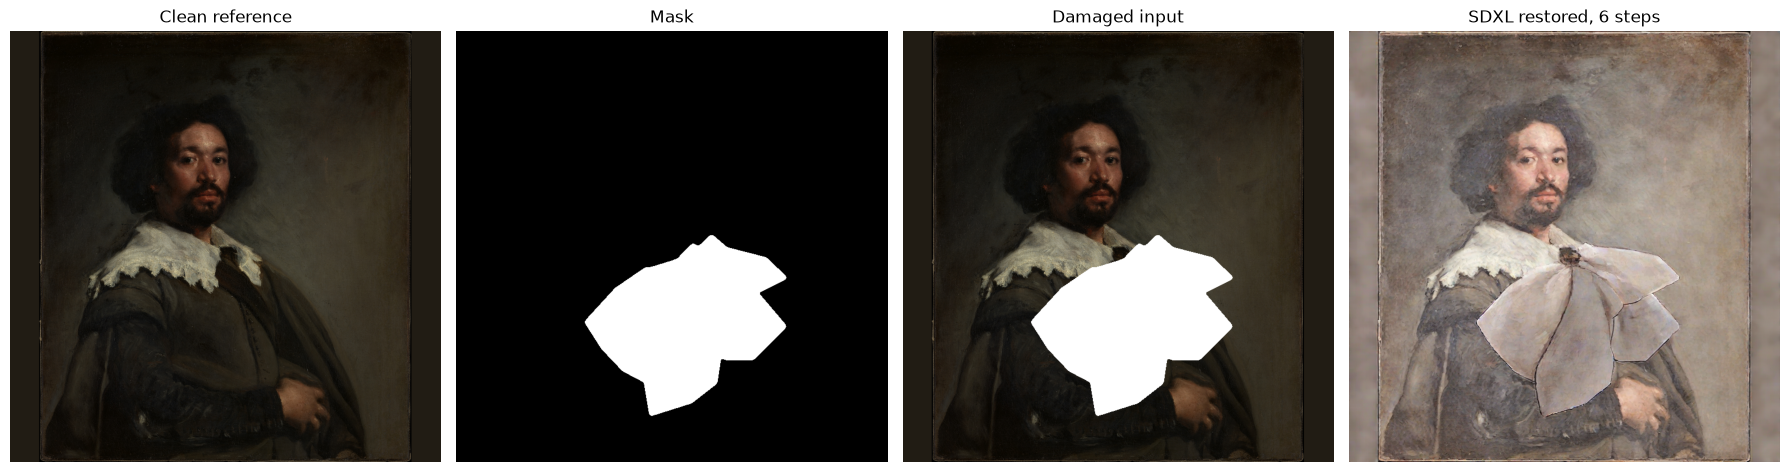

Restored path: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\restored\sdxl_inpainting\smoke_test\p001_loss_large.png
Elapsed seconds: 593.9759607315063


In [10]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

def resolve_project_path(path_value):
    path = Path(str(path_value))
    if path.is_absolute():
        return path
    return PROJECT_ROOT / path

smoke_row = smoke_restored_df_12step.iloc[0]

clean_path = resolve_project_path(smoke_row["clean_path"])
damaged_path = resolve_project_path(smoke_row["damaged_path"])
mask_path = resolve_project_path(smoke_row["mask_path"])
restored_path = resolve_project_path(smoke_row["restored_path"])

clean_img = Image.open(clean_path).convert("RGB")
damaged_img = Image.open(damaged_path).convert("RGB")
mask_img = Image.open(mask_path).convert("L")
restored_img = Image.open(restored_path).convert("RGB")

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(clean_img)
axes[0].set_title("Clean reference")
axes[0].axis("off")

axes[1].imshow(mask_img, cmap="gray")
axes[1].set_title("Mask")
axes[1].axis("off")

axes[2].imshow(damaged_img)
axes[2].set_title("Damaged input")
axes[2].axis("off")

axes[3].imshow(restored_img)
axes[3].set_title("SDXL restored, 6 steps")
axes[3].axis("off")

plt.tight_layout()
plt.show()

print("Restored path:", restored_path)
print("Elapsed seconds:", smoke_row["elapsed_seconds"])

## SDXL feasibility conclusion

SDXL Inpainting was initially planned as a fourth restoration baseline. The model was tested locally on the available RTX 3060 Laptop GPU with 6 GB VRAM.

The model could not be run comfortably without memory-saving settings. Running without CPU offload caused CUDA out-of-memory errors. With CPU offload enabled, SDXL became technically executable but too slow for full evaluation.

Two reduced smoke-test settings were tested:

- 6 inference steps, guidance scale 4.5, 512 × 512 inference, 768 × 768 output,
- 12 inference steps, guidance scale 6.0, strength 1.0, 512 × 512 inference, 768 × 768 output.

The 6-step setting completed but did not produce a usable restoration of the masked region. The 12-step setting produced a completed region but strongly altered the global appearance of the image and required approximately 10 minutes for a single case.

Given this runtime and quality trade-off, SDXL was excluded from the full local controlled evaluation. This decision is treated as a computational feasibility limitation, not as a conclusion about SDXL restoration quality under adequate hardware conditions.

The full controlled comparison therefore remains focused on OpenCV Telea, LaMa, and Stable Diffusion Inpainting. SDXL is reserved for future work or for rerunning on stronger GPU resources.

In [3]:
from datetime import datetime
import pandas as pd

sdxl_feasibility_df = pd.DataFrame(
    [
        {
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "model_name": "sdxl_inpainting",
            "model_id": "diffusers/stable-diffusion-xl-1.0-inpainting-0.1",
            "gpu": "NVIDIA GeForce RTX 3060 Laptop GPU",
            "vram_gb": 6,
            "test_case": "p001_loss_large",
            "setting": "6_steps_512_cpu_offload",
            "num_inference_steps": 6,
            "guidance_scale": 4.5,
            "strength": None,
            "inference_size": 512,
            "output_size": 768,
            "use_cpu_offload": True,
            "runtime_seconds": 267.4,
            "runtime_minutes": 4.56,
            "status": "completed_but_not_usable",
            "observation": "Masked region not meaningfully restored.",
        },
        {
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "model_name": "sdxl_inpainting",
            "model_id": "diffusers/stable-diffusion-xl-1.0-inpainting-0.1",
            "gpu": "NVIDIA GeForce RTX 3060 Laptop GPU",
            "vram_gb": 6,
            "test_case": "p001_loss_large",
            "setting": "12_steps_512_strength_1_cpu_offload",
            "num_inference_steps": 12,
            "guidance_scale": 6.0,
            "strength": 1.0,
            "inference_size": 512,
            "output_size": 768,
            "use_cpu_offload": True,
            "runtime_seconds": 594.0,
            "runtime_minutes": 9.9,
            "status": "completed_but_not_usable",
            "observation": "Masked region filled but output showed strong hallucination and global visual alteration.",
        },
    ]
)

sdxl_feasibility_output_path = PROJECT_ROOT / "outputs" / "metrics" / "sdxl_feasibility_audit_50.csv"
sdxl_feasibility_output_path.parent.mkdir(parents=True, exist_ok=True)
sdxl_feasibility_df.to_csv(sdxl_feasibility_output_path, index=False)

display(sdxl_feasibility_df)
print("Saved:", sdxl_feasibility_output_path)

,timestamp,model_name,model_id,gpu,vram_gb,test_case,setting,num_inference_steps,guidance_scale,strength,inference_size,output_size,use_cpu_offload,runtime_seconds,runtime_minutes,status,observation
0,2026-07-05 23:54:05,sdxl_inpainting,diffusers/stable-diffusion-xl-1.0-inpainting-0.1,NVIDIA GeForce RTX 3060 Laptop GPU,6,p001_loss_large,6_steps_512_cpu_offload,6,4.5,NaN,512,768,True,267.4,4.56,completed_but_not_usable,Masked region not meaningfully restored.
1,2026-07-05 23:54:05,sdxl_inpainting,diffusers/stable-diffusion-xl-1.0-inpainting-0.1,NVIDIA GeForce RTX 3060 Laptop GPU,6,p001_loss_large,12_steps_512_strength_1_cpu_offload,12,6.0,1.0,512,768,True,594.0,9.90,completed_but_not_usable,Masked region filled but output showed strong ...


Saved: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\sdxl_feasibility_audit_50.csv
